# Marketing Mix Modeling: Feature Engineering and Baseline Fit

## Scenario
A growth team wants to understand how weekly marketing channel spend relates to
revenue over time. Your task is to engineer the features needed for a time-aware
marketing mix model — including adstock/carryover features and seasonality controls —
then fit a Ridge regression and evaluate its out-of-sample performance.

## Your task
You will produce:
1. Adstock-transformed features for all 5 marketing channels
2. Time controls: a linear trend variable `t` and weekly seasonality terms (`sin52`, `cos52`)
3. A Ridge regression model fit on the training period
4. Test MAE reported numerically
5. An Actual vs Predicted plot for the test period
6. A written assessment: what does the fit quality imply about model trustworthiness?

## Requirements
- Use `marketing_weekly_channels.csv`
- Apply adstock with `alpha=0.3` to all 5 channels:
  `spend_search`, `spend_social`, `spend_video`, `spend_affiliate`, `spend_email`
- Time-based train/test split: first **80%** of weeks = train, last **20%** = test
- Use `Ridge(alpha=1.0)`; do **not** shuffle the data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Load and sort the weekly data ─────────────────────────────────
df = pd.read_csv(MMM_PATH, parse_dates=['week_start'])
df = df.sort_values('week_start').reset_index(drop=True)
df['t'] = np.arange(len(df))   # integer time index
print(df.shape)
df.head()

(156, 10)


,week_start,spend_search,spend_social,spend_video,spend_affiliate,spend_email,installs,new_subscriptions,weekly_revenue_usd,t
0,2022-01-03,11157.72,3166.13,9609.98,892.09,1235.35,25597,899,10715.40,0
1,2022-01-10,3491.33,4454.75,3802.93,3257.74,1552.97,22440,865,4870.41,1
2,2022-01-17,5802.55,5511.06,2458.08,852.15,869.39,20345,791,16070.33,2
3,2022-01-24,4847.06,5245.37,1438.74,1707.09,970.90,23833,890,-3394.49,3
4,2022-01-31,10290.90,5783.86,2920.74,1654.58,814.64,24693,898,22258.67,4


In [4]:
# ── Step 2: Add seasonality terms ────────────────────────────────────────
# Fourier pair (sin + cos) with 52-week period captures annual seasonality
df['sin52'] = np.sin(2 * np.pi * df['t'] / 52)
df['cos52'] = np.cos(2 * np.pi * df['t'] / 52)

In [5]:
# ── Step 3: Compute adstock features for all 5 channels ──────────────────
def adstock(series, alpha=0.3):
    # Geometric decay carryover: each week's spend decays from prior periods
    result = np.zeros(len(series))
    result[0] = series.iloc[0]
    for i in range(1, len(series)):
        result[i] = series.iloc[i] + alpha * result[i - 1]
    return result

channels = ['spend_search','spend_social','spend_video','spend_affiliate','spend_email']
for ch in channels:
    df[f'{ch}_adstock'] = adstock(df[ch])

print("Adstock columns created:", [f'{ch}_adstock' for ch in channels])

Adstock columns created: ['spend_search_adstock', 'spend_social_adstock', 'spend_video_adstock', 'spend_affiliate_adstock', 'spend_email_adstock']


In [6]:
# ── Step 4: Build feature matrix and time-based split ─────────────────────
adstock_cols  = [f'{ch}_adstock' for ch in channels]
feature_cols  = ['t','sin52','cos52'] + adstock_cols

X = df[feature_cols]
y = df['weekly_revenue_usd']

# Time-based split — NEVER shuffle time-series data
n_train  = int(len(df) * 0.8)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
print(f"Train weeks: {len(X_train)}  |  Test weeks: {len(X_test)}")

Train weeks: 124  |  Test weeks: 32


In [7]:
# ── Step 5: Fit Ridge regression and evaluate ─────────────────────────────
# Ridge regression with L2 penalty reduces sensitivity to collinear channel spends
model_mmm = Ridge(alpha=1.0)
model_mmm.fit(X_train, y_train)

y_pred = model_mmm.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: ${test_mae:,.2f}")

Test MAE: $6,280.84


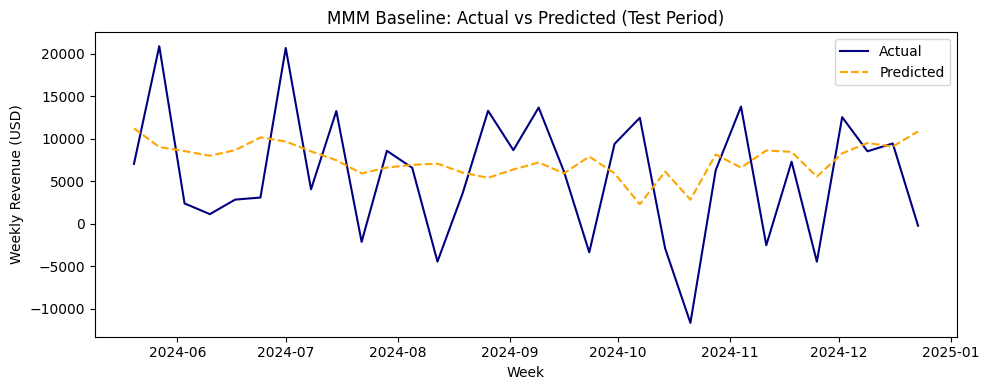

In [8]:
# ── Step 6: Actual vs Predicted plot (test period) ────────────────────────
# Visual check: how well does the model track actual revenue patterns?
test_dates = df['week_start'].iloc[n_train:]

plt.figure(figsize=(10, 4))
plt.plot(test_dates, y_test.values, label='Actual',    color='navy',   linewidth=1.5)
plt.plot(test_dates, y_pred,        label='Predicted', color='orange', linewidth=1.5, linestyle='--')
plt.xlabel("Week")
plt.ylabel("Weekly Revenue (USD)")
plt.title("MMM Baseline: Actual vs Predicted (Test Period)")
plt.legend()
plt.tight_layout()
plt.show()

## Model Fit Assessment

In the markdown cell below, answer:
1. How large is the test MAE relative to the typical weekly revenue range?
   (Check `df['weekly_revenue_usd'].describe()` if needed.)
2. Does the Actual vs Predicted plot suggest the model captures the general trend?
   Are there systematic errors (e.g., consistently over/under-predicting)?
3. Given this fit quality, would you trust this model's channel coefficients for
   budget reallocation decisions? What would you want to validate first?

In [9]:
# Reference stats for fit assessment
rev_stats = df['weekly_revenue_usd'].describe()
print("Revenue stats:")
print(rev_stats.round(0))
print()
print(f"Test MAE:        ${test_mae:,.0f}")
print(f"Revenue std dev: ${rev_stats['std']:,.0f}")
print(f"MAE / std:       {test_mae / rev_stats['std']:.2f}  (lower is better; <0.5 is reasonable)")
print()
print("Interpretation: if MAE < 0.5 × std, the model captures meaningful signal.")
print("Always pair with Actual vs Predicted visual check for systematic bias.")
print("\n⚠  Note: weekly_revenue_usd contains negative values (min ~−$12k).")
print("   This reflects net revenue after refunds, chargebacks, and subscription")
print("   cancellation credits in the billing period. Negative weeks occur when")
print("   payouts exceed gross new revenue. Ridge regression handles this natively.")


Revenue stats:
count      156.0
mean      8022.0
std       8362.0
min     -12457.0
25%       1249.0
50%       8123.0
75%      13497.0
max      34612.0
Name: weekly_revenue_usd, dtype: float64

Test MAE:        $6,281
Revenue std dev: $8,362
MAE / std:       0.75  (lower is better; <0.5 is reasonable)

Interpretation: if MAE < 0.5 × std, the model captures meaningful signal.
Always pair with Actual vs Predicted visual check for systematic bias.

⚠  Note: weekly_revenue_usd contains negative values (min ~−$12k).
   This reflects net revenue after refunds, chargebacks, and subscription
   cancellation credits in the billing period. Negative weeks occur when
   payouts exceed gross new revenue. Ridge regression handles this natively.
